<h1 align="center">GCM CORRECTION NOTEBOOK</h1> 
<hr></hr>
<b>This Notebook is for correcting the GCMs outputs data before using it for <i>Elmer/Ice</i> simulations</b>.

Statistical correction method : 
- Monthly empirical quantile delta mapping for temperature
- Temperature-coupled monthly empirical quantile mapping for precipitation

<b>Modification V. Peyaud 13/05/2026 for MPI SSP245</b>.

In [72]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import proplot as plot
from scipy.stats import rv_histogram as pystat
import datetime
import cftime

import warnings 
warnings.filterwarnings("ignore",category=FutureWarning)

#Define reference time for correction (same period as SAFRAN data)
ref_time=slice('1975','2014');
latARG=45.9833
lonARG= 6.9333

In [2]:
#aaa

In [3]:
# Which Computer ?
#path_DIR = '/bettik/beaumetj/'  # On dahu
path_DIR = '/Users/peyaudv/Glaciers/MAR_GCMs/' # Local pc perso
path_IMG = path_DIR+'SavedFigures/'
dirinSAF = 'safran/'
dirinMQM = 'zeno_nb/GCM_simpleMQM/' 

In [4]:
# Some lists
month=['January','February','March','April','May','June',
      'July','August','September','October','November','December']
                #                                   #
colorsMonth = [                                     #
    "#1f77b4",  # Bleu (Janvier - Hiver)            #
    "#aec7e8",  # Bleu clair (Février - Hiver)      #
    "#2ca02c",  # Vert (Mars - Printemps)           # 
    "#98df8a",  # Vert clair (Avril - Printemps     #
    "#ffbb78",  # Orange clair Mai - Printemps)     #    
    "#ff7f0e",  # Orange (Juin - Été)               # 
    "#d62728",  # Rouge (Juillet - Été)             # 
    "#ff9896",  # Rouge clair (Août - Été)          # 
    "#9467bd",  # Violet (Septembre - Automne)      #
    "#8c564b",  # Marron Octobre - Automne          #
    "#c49c94",   # Marron clair (Novembre - Automne) #
    "#c5b0d5"  # Violet clair (Décembre - Hiver)   #
]

## SAFRAN

In [5]:
#Load SAFRAN reference temperature data (From Adrien Gilbert 2026)
temp_saf_ndarray = np.loadtxt(dirinSAF+'SafranDailyTemp_1959_2023_MtBlanc.dat', delimiter=',', unpack=True)
prec_saf_ndarray = np.loadtxt(dirinSAF+'SafranDailyPrecip_1959_2023_MtBlanc.dat', delimiter=',', unpack=True)
len(temp_saf_ndarray)

23954

In [6]:
# Convert dates
# 1. Date format
date_format = "%m/%d/%Y"
dateG = datetime.datetime.strptime('1/01/1959', date_format)
dateC = datetime.datetime.strptime('1/01/1975', date_format)

# 2. Nb of days between starting dates of Clauzel and 
delta = dateC - dateG
print("Nb of days between starting dates of Clauzel and GilbGilbert ert: ",delta.days) 
date2Index = np.arange(-delta.days, len(temp_saf_ndarray)-delta.days, 1)#

# 3. Creer une plage de dates pour les donnees SAFRAN Gilbert  (1 date par jour)
dates2 = pd.date_range(start='1/01/1959', periods=len(temp_saf_ndarray), freq="D")

Nb of days between starting dates of Clauzel and GilbGilbert ert:  5844


In [7]:
# Conversion en DataArray avec des coordonnées temporelle
temp_saf = xr.DataArray( temp_saf_ndarray, dims=["time"], coords={"time": dates2} )
prec_saf = xr.DataArray( prec_saf_ndarray, dims=["time"], coords={"time": dates2} )

# 1. MPI (ESM1-2-HR_histo_ssp245_r1i1p1f1)

## 1.1 MPI : Temperature correction calibration

In [13]:
##Load hist-CMIP temperature
temp_ssp=xr.open_dataset(path_DIR+'/GCM/MPI-ESM1-2-HR/full_arg_tas_day_MPI-M_MPI-ESM1-2-HR_histo_ssp245_r1i1p1f1.nc').tas # new rep IPSL_CDQM_hist/ by Vince 
print('lon=',temp_ssp.lon[0].values,', lat=',temp_ssp.lat[0].values) 
temp_ssp=temp_ssp.sel(lon=temp_ssp.lon[0],lat=temp_ssp.lat[0] ).drop('lon').drop('lat').drop('height')-273.15 # remove useless coordinates
temp_ssp

lon= 6.98 , lat= 45.95


<xarray.DataArray 'tas' (time: 91676)> Size: 367kB
array([-1.9289551, -3.330536 , -6.6690063, ...,  1.5466003,  2.1961975,
       -1.7848206], shape=(91676,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 733kB 1850-01-01T12:00:00 ... 2100-12-31T1...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T06:42:13Z altered by CMOR: Treated scalar dime...
    institution:    MPIMET

In [14]:
temp_lim=(-30,30)
bins_t=int(temp_lim[1]*2/0.1)
print(bins_t)

600


Text(0.5, 0.92, 'MPI daily tas histogram by month')

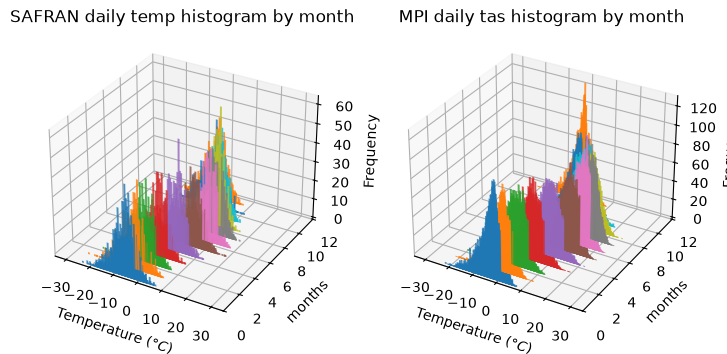

In [15]:
# Plot 3D Histograms by month SAFRAN and GCM

fig = plt.figure(figsize=(8.5, 4))
axs = fig.add_subplot(121, projection='3d')
axd = fig.add_subplot(1, 2, 2, projection='3d')
for m in range(12):#loop over month
    ##SAFRAN
    #print(m)
    # Filter data for the specific month (m+1)
    monthly_data = temp_ssp.where(temp_ssp.time.dt.month == m+1, drop=True)
    monthly_safr = temp_saf.where(temp_saf.time.dt.month == m+1, drop=True)
    
    counts_d, bins_d = np.histogram(monthly_data, bins=bins_t, range=temp_lim) ### retourne des 0
    counts_s, bins_s = np.histogram(monthly_safr, bins=bins_t, range=temp_lim)
    
    axs.bar( bins_s[1:], counts_s, zs=m, zdir='y', alpha=0.8)
    axd.bar( bins_d[1:], counts_d, zs=m, zdir='y', alpha=0.8)
#
axs.set_xlabel('Temperature ($°C$)')
axs.set_ylabel('months')
axs.set_zlabel('Frequency')
#
axd.set_xlabel('Temperature ($°C$)')
axd.set_ylabel('months')
axd.set_zlabel('Frequency')
#
axs.set_ylim(0,12)
axd.set_ylim(0,12)
#
axs.set_title(f'SAFRAN daily temp histogram by month')
axd.set_title(f'MPI daily tas histogram by month')

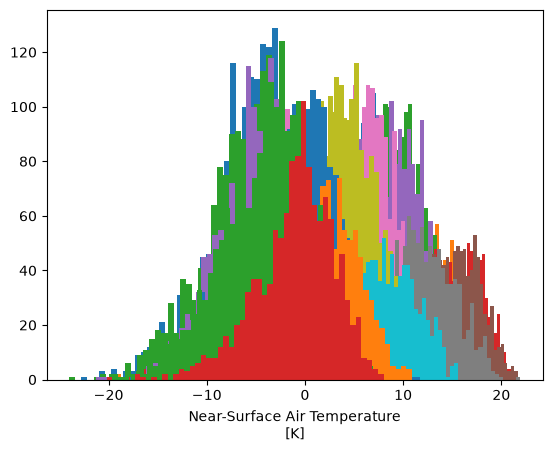

In [16]:
###Derive temperature monthly CDF###
bins=50
#initialize array :
temp_saf_dist=[]
temp_ssp_dist=[]
for m in range(12):#loop over month
    ##SAFRAN
    dist=pystat(temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).plot.hist(bins=bins)[0:2])#,range=temp_lim
    temp_saf_dist+=[dist]
    ##Hist-CMIP
    dist=pystat(temp_ssp.sel(time=ref_time).where(temp_ssp.time.dt.month==m+1,drop=True).plot.hist(bins=bins)[0:2])
    temp_ssp_dist+=[dist]

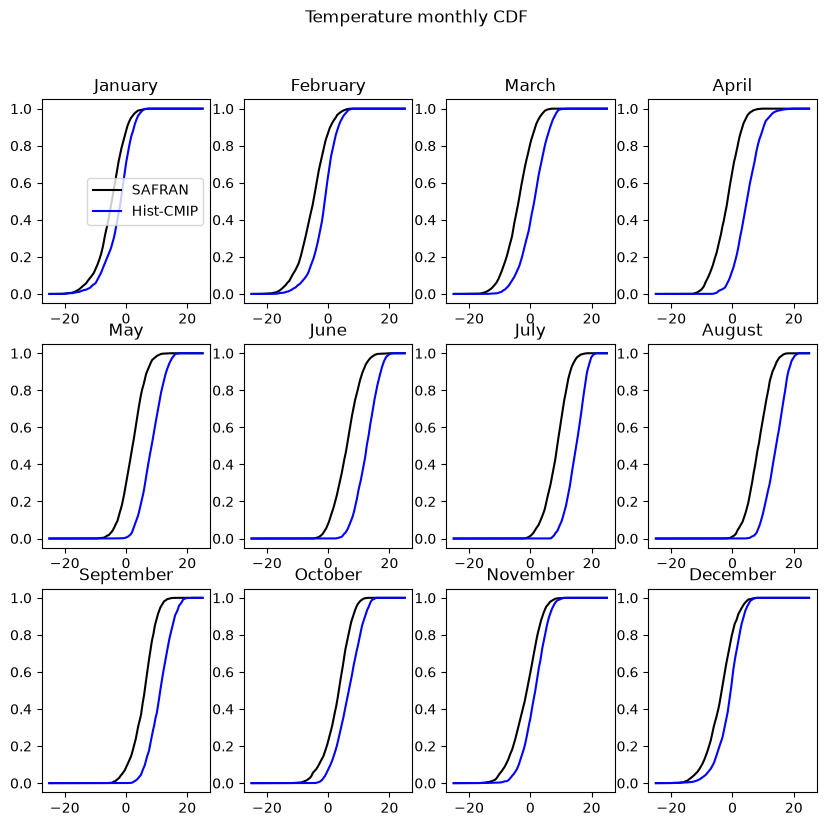

In [17]:
###Plot CDF###
month=['January','February','March','April','May','June',
      'July','August','September','October','November','December']
fig, axs = plt.subplots(nrows=3,ncols=4,figsize=(10,9));
fig.suptitle('Temperature monthly CDF')
val_temp=np.arange(-25,25,0.01)
for m in range(12):
    ax=axs.flatten()[m]
    ax.set_title(month[m])
    ax.plot(val_temp,temp_saf_dist[m].cdf(val_temp),c='black',label='SAFRAN');
    ax.plot(val_temp,temp_ssp_dist[m].cdf(val_temp),c='blue',label='Hist-CMIP');
axs[0,0].legend();

## 1.2 Correction MPI Temperatures

**SQM Correction (see Cannon 2015)**

$X_{m, p}$ Data : historical observations, $X_{m, p}$ Modeled Dataset, projection, etc...

$F_{o,h} = CDF{observ, historic}$ is the Cumuled Distribution Function of historical observations

$F_{o,m} = CDF{model, historic}$

$F^{-1}_{o,h} = PPF{observ, historic}$ (inverse of CDF)

**Note** : $X_{o,h} = F^{-1}_{o,h} [ F_{o,h} (X_{o,h}) ]$ by construction

**QM : Quantile Mapping (standard)**
$Xcor^{QM}_{m,p} = F^{-1}_{o,h} [ F_{m,h} (X_{m,p}) ]$

**QDM : : Quantile Delta Mapping** as in Cannon 2015, Annexe A

$T m,p(t) = F(t)_{m,p} [X_{m, p}(t)] $ is the nonexceedance probability associated with the value X at time t

$Xcor^{QDM}_{m,p} = X_{m,p} +  F^{-1}_{o,h} [ T m,p(t) ] - F^{-1}_{m,h} [ T m,p(t) ]$

corrected = original + (target_distribution_at_quantile - historical_distribution_at_same_quantile)

additive correction in value space, not a replacement mapping.
That assumes:
•	bias is additive, 
•	Distribution shift is stationary within each month/year slice.

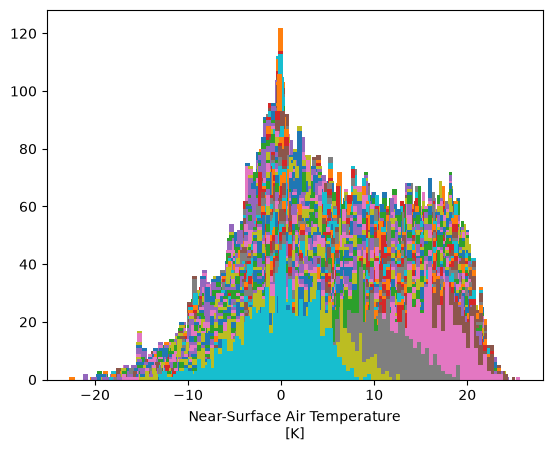

In [18]:
###Derive rolling CDF###
temp_rolling_cdf=[[] for m in range(12)]
for y in range(1850,2100):
    for m in range(12):#loop over month
        dist=pystat(temp_ssp.sel(time=slice(str(y-20),str(y+19))).where(temp_ssp.time.dt.month==m+1,drop=True).plot.hist(bins=50)[0:2])
        temp_rolling_cdf[m]+=[dist]

**QDM correction For Temperature**

In [19]:
###Correction### QDM For Temperature
temp_ssp_cor=temp_ssp.copy()
for m in range(1,13):
    print(m)
    for y in range(1850,2100):
        temp_ssp_cor=xr.where((temp_ssp_cor.time.dt.year==y) & (temp_ssp_cor.time.dt.month==m),
                               temp_ssp_cor+temp_saf_dist[m-1].ppf(temp_rolling_cdf[m-1][y-1850].cdf(temp_ssp_cor))-temp_ssp_dist[m-1].ppf(temp_rolling_cdf[m-1][y-1850].cdf(temp_ssp_cor)),
                               temp_ssp_cor)
temp_ssp_cor

1
2
3
4
5
6
7
8
9
10
11
12


<xarray.DataArray (time: 91676)> Size: 733kB
array([-4.62185219, -6.30445738, -9.24535318, ...,  1.54660034,
        2.19619751, -1.78482056], shape=(91676,))
Coordinates:
  * time     (time) datetime64[ns] 733kB 1850-01-01T12:00:00 ... 2100-12-31T1...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T06:42:13Z altered by CMOR: Treated scalar dime...
    institution:    MPIMET

In [20]:
##Save to netCDF file
#temp_hist_cor.to_netcdf
temp_ssp_cor.to_netcdf('./MPI_hist_ssp245_temp_hist_cor.nc')


## 1.3 Precipitation Calibration

*WARNING From Clauzel:* Correct temperature before calibrating precipitation correction

Indeed is below in the script but must be runned before & then called here (note from Peyaud)

In [21]:
### The temp_ssp_cor are calculated above. no need to open a file this day since 24/06/2026

if (False):
    ##Load ssp temperature corrected
    #prec_hist=xr.open_dataarray('IPSL_2Dcor/IPSL_pr_hist_daily.nc').round(4)
    temp_ssp_cor=xr.open_dataarray(dirinMQM+'temp_ssp_cor.nc').round(4)
    temp_ssp_cor=temp_ssp_cor[:,0,0] # keep just time dimension (remove lon,lat)
    temp_ssp_cor

In [22]:
##Load ssp precipitation
prec_ssp=xr.open_dataset(path_DIR+'/GCM/MPI-ESM1-2-HR/full_arg_pr_day_MPI-M_MPI-ESM1-2-HR_histo_ssp245_r1i1p1f1.nc').pr
print('lon=',prec_ssp.lon[0].values,', lat=',prec_ssp.lat[0].values) 
prec_ssp = prec_ssp.sel(lon=prec_ssp.lon[0],lat=prec_ssp.lat[0] ).drop('lon').drop('lat')*86.4 #3600*24/1000 # From m/s (kg m-2 s-1) to mm/d 
prec_ssp                        # & keep just time dimension (remove lon,lat)

lon= 6.98 , lat= 45.95


<xarray.DataArray 'pr' (time: 91676)> Size: 367kB
array([2.8936678e-04, 6.6996220e-04, 5.0944707e-04, ..., 1.1627376e-05,
       3.6216511e-03, 9.6216686e-03], shape=(91676,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 733kB 1850-01-01T12:00:00 ... 2100-12-31T1...
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          kg m-2 s-1
    comment:        includes both liquid and solid phases
    original_name:  pr
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T06:42:13Z altered by CMOR: replaced missing va...
    institution:    MPIMET

In [23]:
###Derivation of temperature intensity quantiles
nq=5 #quantile number
temp_range=np.zeros((12,nq+1))
for m in range(12):
    temp_range[m,:]=temp_saf.where(temp_saf.time.dt.month==m+1,drop=True).quantile(np.arange(0,1+1/1000,1/nq)).values
temp_range[:,0]=-30
temp_range[:,-1]=30
print('Temperature group boundaries (lines=months):')
temp_range

Temperature group boundaries (lines=months):


array([[-30.  ,  -8.4 ,  -5.7 ,  -3.6 ,  -1.3 ,  30.  ],
       [-30.  ,  -8.92,  -6.2 ,  -3.8 ,  -1.28,  30.  ],
       [-30.  ,  -7.8 ,  -5.  ,  -2.8 ,  -0.2 ,  30.  ],
       [-30.  ,  -5.6 ,  -2.8 ,  -0.7 ,   1.7 ,  30.  ],
       [-30.  ,  -1.1 ,   1.2 ,   3.2 ,   5.2 ,  30.  ],
       [-30.  ,   2.2 ,   4.9 ,   7.1 ,   9.6 ,  30.  ],
       [-30.  ,   5.3 ,   7.9 ,   9.7 ,  11.7 ,  30.  ],
       [-30.  ,   5.2 ,   7.4 ,   9.5 ,  11.6 ,  30.  ],
       [-30.  ,   2.5 ,   5.1 ,   7.  ,   8.9 ,  30.  ],
       [-30.  ,  -0.5 ,   2.4 ,   4.4 ,   6.6 ,  30.  ],
       [-30.  ,  -5.6 ,  -2.4 ,   0.  ,   2.3 ,  30.  ],
       [-30.  ,  -7.62,  -4.6 ,  -2.4 ,  -0.2 ,  30.  ]])

In [24]:
# Create a new dimension of length nq
TQuant_dim = np.arange(nq)
T_month_dim= np.arange(12)
# Expand the existing array with the new dimension
new_data = np.zeros((len(prec_ssp.time.sel(time=ref_time)), len(TQuant_dim), len(T_month_dim)))
prec_ssp_byQofT = xr.DataArray(
    new_data,
    dims=["time", "dim_TempRange", "dim_months"],
    coords={"time": prec_ssp.time.sel(time=ref_time), "dim_TempRange": TQuant_dim, "dim_months":T_month_dim }
)

In [25]:
temp_range.shape

(12, 6)

In [26]:
### How to create a DataArray of a given size...
# not used anymore
# coords = {"months": range(12), "QuantOfTemp": range(5), "time": prec_ssp.time.sel(time=ref_time).values}
#coords = {"b": range(5), "c": range(3), }
#da = xr.DataArray(np.zeros([ 12, 5, prec_ssp.shape[0] ]), coords=coords, dims=list(coords.keys()))

In [27]:
# Méthode 1 : Compréhension de liste
prec_ssp_byQofT = [[0 for _ in range(nq)] for _ in range(12)]
#prec_ssp_byQofT[0][0]=aaa
#prec_ssp_byQofT

In [28]:
temp_range

array([[-30.  ,  -8.4 ,  -5.7 ,  -3.6 ,  -1.3 ,  30.  ],
       [-30.  ,  -8.92,  -6.2 ,  -3.8 ,  -1.28,  30.  ],
       [-30.  ,  -7.8 ,  -5.  ,  -2.8 ,  -0.2 ,  30.  ],
       [-30.  ,  -5.6 ,  -2.8 ,  -0.7 ,   1.7 ,  30.  ],
       [-30.  ,  -1.1 ,   1.2 ,   3.2 ,   5.2 ,  30.  ],
       [-30.  ,   2.2 ,   4.9 ,   7.1 ,   9.6 ,  30.  ],
       [-30.  ,   5.3 ,   7.9 ,   9.7 ,  11.7 ,  30.  ],
       [-30.  ,   5.2 ,   7.4 ,   9.5 ,  11.6 ,  30.  ],
       [-30.  ,   2.5 ,   5.1 ,   7.  ,   8.9 ,  30.  ],
       [-30.  ,  -0.5 ,   2.4 ,   4.4 ,   6.6 ,  30.  ],
       [-30.  ,  -5.6 ,  -2.4 ,   0.  ,   2.3 ,  30.  ],
       [-30.  ,  -7.62,  -4.6 ,  -2.4 ,  -0.2 ,  30.  ]])

**rem:** temp_ssp_cor[:,0,0] because in this execution scheme (there is lon lat coordinates)

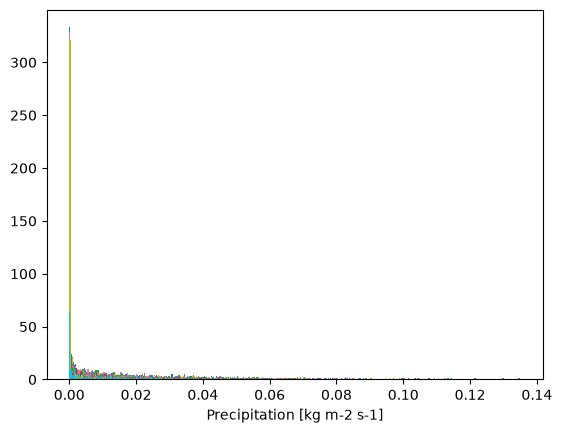

In [30]:
###Derive monthly and temperature quantile precipitation CDF###
bins=250
#initialize array : first dimension is temperature groups, second dimension is months
prec_ssp_dist=[[] for i in range(nq)]
prec_saf_dist=[[] for i in range(nq)]


for t in range(nq):
    #print(t,nq,m)
    # For plotting: keep a arrzy with prec by quantile
    
    #print("aaa",aaa)
    #prec_ssp_byQofT.append(aaa)
    for m in range(12):#loop over month
        #print(t,m)
        ##SAFRAN
        prec_saf_dist[t]+=[pystat(prec_saf.where(prec_saf.time.dt.month==m+1,drop=True).where((temp_saf>temp_range[m,t])&(temp_saf<=temp_range[m,t+1]),drop=True).plot.hist(bins=bins)[0:2])]
        ##Model MPI
        prec_ssp_dist[t]+=[pystat(prec_ssp.sel(time=ref_time).where(prec_ssp.time.dt.month==m+1,drop=True).where((temp_ssp_cor>temp_range[m,t])&(temp_ssp_cor<=temp_range[m,t+1]),drop=True).plot.hist(bins=bins)[0:2])]
        # For plotting: keep a arrzy with prec by quantile
        #prec_ssp_byQofT[m][t] = prec_ssp.where((temp_ssp_cor[:,0,0]>temp_range[m,t])&(temp_ssp_cor[m,0,0]<=temp_range[m,t+1]),drop=True)
### Notes :
# drop=True dans where supprime les coordonnées qui ne satisfont pas la condition. 
# prec_saf et temp_saf doivent avoir les mêmes dimensions (ou être broadcastables)
# [0:2] prend n et bins

In [ ]:
#prec_ssp_byQofT

In [31]:
# Calculate mean
print(temp_range[:,:])
print(np.mean(temp_range[:,0]))

[[-30.    -8.4   -5.7   -3.6   -1.3   30.  ]
 [-30.    -8.92  -6.2   -3.8   -1.28  30.  ]
 [-30.    -7.8   -5.    -2.8   -0.2   30.  ]
 [-30.    -5.6   -2.8   -0.7    1.7   30.  ]
 [-30.    -1.1    1.2    3.2    5.2   30.  ]
 [-30.     2.2    4.9    7.1    9.6   30.  ]
 [-30.     5.3    7.9    9.7   11.7   30.  ]
 [-30.     5.2    7.4    9.5   11.6   30.  ]
 [-30.     2.5    5.1    7.     8.9   30.  ]
 [-30.    -0.5    2.4    4.4    6.6   30.  ]
 [-30.    -5.6   -2.4    0.     2.3   30.  ]
 [-30.    -7.62  -4.6   -2.4   -0.2   30.  ]]
-30.0


100


Text(0.5, 0.98, 'Precipitation histograms per Quantile of Temp and per month')

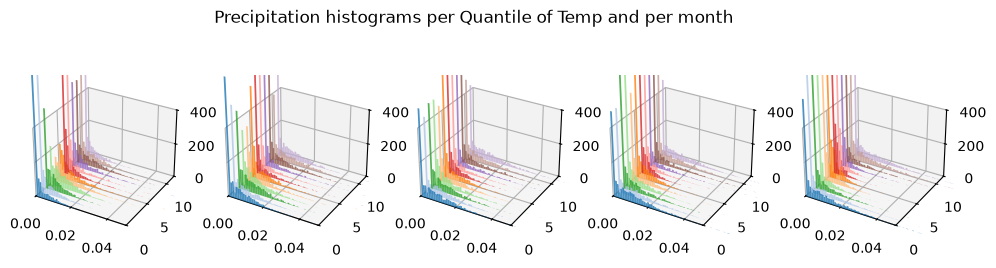

In [33]:
# Plot 3D Histograms by month SAFRAN and GCM
prec_lim=(0,.1)
bins_p=int(prec_lim[1]/0.001)
print(bins_p)

### For precipitation by 5 quantile of temp
fig, axs = plt.subplots(nrows=1,ncols=5,figsize=(12,3), subplot_kw={"projection": "3d"});

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"}) 

#t=0
for t in range(5): # Quantile of T
  ax = axs[t]
  for m in range(12):#loop over month
    ##SAFRAN
    #
    #print(t,m)
    # Filter data for the specific month (m+1)
    #monthly_data = prec_ssp.where(prec_ssp.time.dt.month == m+1, drop=True) # prec_ssp /mois
    monthly_data = prec_ssp.where(prec_ssp.time.dt.month == m+1).where((temp_ssp_cor>temp_range[m,t])&(temp_ssp_cor<=temp_range[m,t+1]), drop=True) # prec_ssp /mois /quantile
    #monthly_data = prec_ssp_byQofT[m][t]#.where(prec_ssp_byQofT[m][t].time.dt.month == m+1, drop=True)#[:,0,0] 
    counts_d, bins_d = np.histogram(monthly_data, bins=bins_p, range=prec_lim)
    #print( counts_d)
    ax.bar( bins_d[1:], counts_d[:], zs=m, zdir='y', alpha=0.8,color=colorsMonth[m],width=.001 )
    #print()
  #ax.set_title(f'{np.mean(temp_range[:,t]):.1f}<T<{np.mean(temp_range[m,t+1]):.1f}')
  #
  ax.set_xlim(0,.05)
  ax.set_ylim(0,12)
  ax.set_zlim(0,400)
fig.suptitle('Precipitation histograms per Quantile of Temp and per month')

In [34]:
bins_d[1:].shape, counts_d.shape

((100,), (100,))

**Plot**

In [35]:
# Calculate Trends 
# Define reference time for correction (same period as SAFRAN data)
ref_time=slice('1975','2014')
print ('Temperature rerence 1975-2014')
# For each run
### Calcul reference temp for the run
### Derive temperature trend (rolling avege Temp(t) t-15y < t < t+15y)

#temp_saf
ref=temp_saf.sel(time=ref_time).mean()
print('temp_saf', ref.values)
temp_saf_trend=(temp_saf.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist
#ref=temp_hist.sel(time=ref_time).mean()
#temp_hist_trend=(temp_hist.groupby('time.year').mean('time').mean('realization')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist_cor
#ref=temp_hist_cor.sel(time=ref_time).mean()
#temp_hist_cor_trend=(temp_hist_cor.groupby('time.year').mean('time').mean('realization')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist_ssp
ref=temp_ssp.sel(time=ref_time).mean()
print('temp_ssp', ref.values)
temp_ssp_trend=(temp_ssp.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist_ssp_cor
ref=temp_ssp_cor.sel(time=ref_time).mean()
print('temp_ssp_cor', ref.values)
temp_ssp_cor_trend=(temp_ssp_cor.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

Temperature rerence 1975-2014
temp_saf 0.992867898699521
temp_ssp 5.7951937
temp_ssp_cor 1.017763555716043


(1900, 2050)

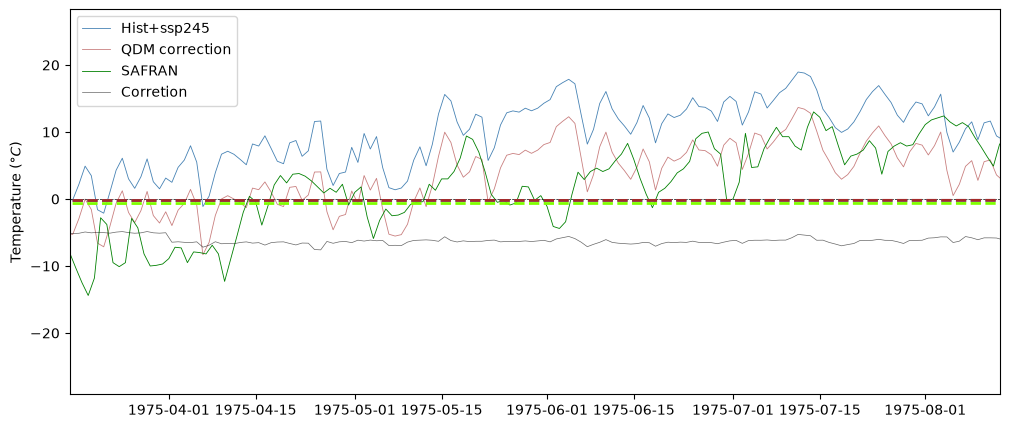

In [37]:
# Plot corrections.
fig, ax = plt.subplots( figsize=(12, 5))

ax.plot(temp_ssp.time,temp_ssp,linestyle='-',color='steelblue',linewidth=0.6,label='Hist+ssp245')
ax.plot(temp_ssp.time,temp_ssp_cor,linestyle='-',color='brown',alpha=.6,linewidth=0.6,label='QDM correction')

ax.plot(temp_saf.time,temp_saf,linestyle='-',color='green',alpha=1.0,linewidth=0.6,label='SAFRAN')

ax.plot(temp_ssp.time,temp_ssp_cor-temp_ssp,linestyle='-',color='k',alpha=.6,linewidth=0.5,label='Corretion')
plt.axhline(y=0., color='k', linestyle='--',lw=0.5)

#Trends
dates_gcm = pd.date_range(f'{temp_ssp_cor_trend.year.values[0]}-01-01', f'{temp_ssp_cor_trend.year.values[-1]}-01-01', freq='YS')
ax.plot(dates_gcm,temp_ssp_trend,color='steelblue',lw=2,ls='--')
ax.plot(dates_gcm,temp_ssp_cor_trend,color='brown',lw=2,ls='--')
dates_saf = pd.date_range(f'{temp_saf_trend.year.values[0]}-01-01', f'{temp_saf_trend.year.values[-1]}-01-01', freq='YS')
ax.plot(dates_saf,temp_saf_trend,color='chartreuse',lw=2,ls='--')

ax.legend()
ax.set_ylabel('Temperature ($°C$)')

#ax.set_xlim( pd.date_range(f'1955-01-01'), pd.date_range(f'2025-01-01') )
ax.set_xlim(1900,2050)

## 1.4 Precipitation Correction

In [38]:
##Derive rolling temperature intensity quantiles##
temp_range_rolling=np.zeros((250,12,nq+1)) #2100-1850+1
for y in range(1850,2100):
    if y % 10 == 0 : print(y)
    for m in range(1,13):
        temp_range_rolling[y-1850,m-1,:]=temp_ssp_cor.sel(time=slice(str(y-20),str(y+19))).where(temp_ssp_cor.time.dt.month==m,drop=True).quantile(np.arange(0,1.0001,1/nq)).values
temp_range_rolling[:,:,0]=-50
temp_range_rolling[:,:,-1]=50

1850
1860
1870
1880
1890
1900
1910
1920
1930
1940
1950
1960
1970
1980
1990
2000
2010
2020
2030
2040
2050
2060
2070
2080
2090


**SQM correction For Precipitation (within 5 Quantile ot T -to preserve pattern for extremes + an - Temp)**

In [39]:
##Correction##
prec_ssp_cor=prec_ssp.copy()
for y in range(1850,2100):
    for m in range(1,13): # months
        for t in range(nq): # quantiles of temp
            prec_ssp_cor=xr.where((prec_ssp_cor.time.dt.month==m)
                               &(prec_ssp_cor.time.dt.year==y)
                               &(temp_ssp_cor>=temp_range_rolling[y-1850,m-1,t])
                               &(temp_ssp_cor<=temp_range_rolling[y-1850,m-1,t+1]),
                               prec_ssp_cor*0+prec_saf_dist[t][m-1].ppf(prec_ssp_dist[t][m-1].cdf(prec_ssp_cor)),
                               prec_ssp_cor)
    if y % 10 == 0 : print(y)

1850
1860
1870
1880
1890
1900
1910
1920
1930
1940
1950
1960
1970
1980
1990
2000
2010
2020
2030
2040
2050
2060
2070
2080
2090


Text(0, 0.5, 'Precip ($mm~d^{-1}$)')

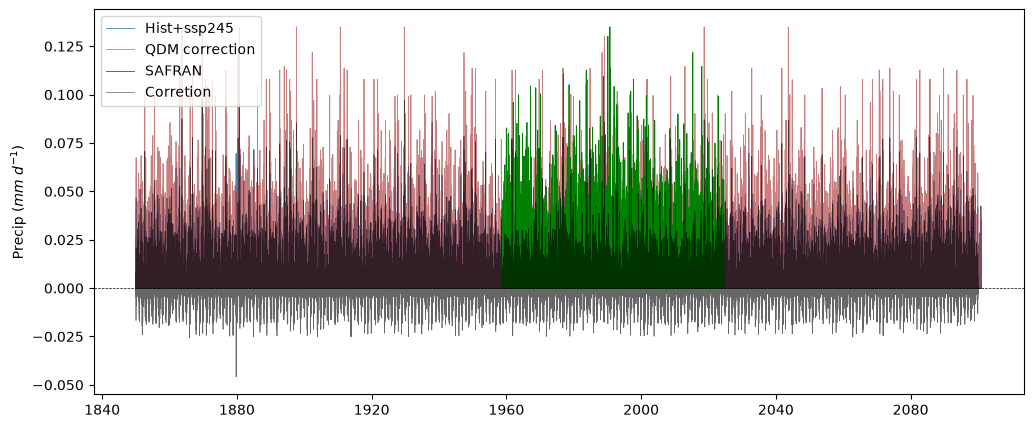

In [40]:
# Plot corrections.
fig, ax = plt.subplots( figsize=(12, 5))

ax.plot(prec_ssp.time,prec_ssp,linestyle='-',color='steelblue',linewidth=0.6,label='Hist+ssp245')
ax.plot(prec_ssp.time,prec_ssp_cor,linestyle='-',color='brown',alpha=.6,linewidth=0.6,label='QDM correction')

ax.plot(prec_saf.time,prec_saf,linestyle='-',color='green',alpha=1.0,linewidth=0.6,label='SAFRAN')

ax.plot(prec_ssp.time,prec_ssp_cor-prec_ssp,linestyle='-',color='k',alpha=.6,linewidth=0.5,label='Corretion')
plt.axhline(y=0., color='k', linestyle='--',lw=0.5)
ax.legend()
ax.set_ylabel('Precip ($mm~d^{-1}$)')

In [41]:
##Save to netCDF file
prec_ssp_cor.to_netcdf('./MPI_hist_ssp245_prec_hist_cor.nc')    

## 2. Figures

In [69]:
# Simple Quantile Mapping made in simpleMQM_correction_Notebook_vince_MPIssp245
#dirouMQM = 'GCM_simpleMQM/' 
temp_ssp_cor_sqm=xr.open_dataset('/Users/peyaudv/Glaciers/GlacioclimProject/Zenodo_repo/Notebooks/GCM_simpleMQM/'+'temp_ssp_cor_simpleMQM.nc').tas
#temp_ssp_cor_sqm

prec_ssp_cor_sqm=xr.open_dataset('/Users/peyaudv/Glaciers/GlacioclimProject/Zenodo_repo/Notebooks/GCM_simpleMQM/'+'prec_ssp_cor_simpleMQM.nc').pr
#prec_ssp_cor_sqm

In [73]:
temp_histalp=xr.open_dataset('/Users/peyaudv/Glaciers/GlacioclimProject/Zenodo_repo/Observational_data/HISTALP/HISTALP_temperature_1780-2014.nc',decode_times=False)
temp_histalp['time']=cftime.num2date(temp_histalp['time'],'months since 1780-01-15 00:00:00',calendar='360_day')
lat_ARG=slice(45.9,46)
lon_ARG=slice(6.9,7.1)
temp_histalp=temp_histalp.sel(lat=lat_ARG,lon=lon_ARG).mean('lat').mean('lon').T_2M

In [74]:
temp_histalp

<xarray.DataArray 'T_2M' (time: 2820)> Size: 11kB
array([-10.083333 , -10.333333 ,  -3.2166665, ...,   0.7666667,
         1.1      ,  -4.25     ], shape=(2820,), dtype=float32)
Coordinates:
  * time     (time) object 23kB 1780-01-15 00:00:00 ... 2014-12-15 00:00:00
Attributes:
    long_name:  2m temperature
    units:      degrees Celcius

In [94]:
#Define reference time for correction (same period as SAFRAN data)
ref_time=slice('1975','2014')
print ('Temperature reference 1975-2014')
# For each run
### Calcul reference temp for the run
### Derive temperature trend (rolling avege Temp(t) t-15y < t < t+15y)

#temp_saf
ref=temp_saf.sel(time=ref_time).mean()
ref_saf=ref
print('Ref temp_saf', ref.values)
temp_saf_trend=(temp_saf.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist_ssp
ref=temp_ssp.sel(time=ref_time).mean()
ref_ssp=ref
print('Ref temp_ssp', ref.values)
temp_ssp_trend=(temp_ssp.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist_ssp_cor
ref=temp_ssp_cor.sel(time=ref_time).mean()
ref_cor=ref
print('Ref temp_ssp_cor', ref.values)
temp_ssp_cor_trend=(temp_ssp_cor.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_hist_ssp_cor_sqm
ref=temp_ssp_cor.sel(time=ref_time).mean()
ref_sqm=ref
print('Ref temp_ssp_cor_sqm', ref.values)
temp_ssp_cor_sqm_trend=(temp_ssp_cor_sqm.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#temp_histalp
ref=temp_histalp.sel(time=ref_time).mean()
ref_histalp=ref
print('Ref temp_histalp', ref.values)
temp_histalp_trend=(temp_histalp.groupby('time.year').mean('time')-ref).rolling(year=30,center=True,min_periods=15).mean()

#Dates for trends
dates_trendsaf = pd.date_range(f'{temp_saf_trend.year.values[0]}-01-01', f'{temp_saf_trend.year.values[-1]}-01-01', freq='YS')

dates_trends = pd.date_range(f'{temp_ssp_cor_trend.year.values[0]}-01-01', f'{temp_ssp_cor_trend.year.values[-1]}-01-01', freq='YS')


Temperature reference 1975-2014
Ref temp_saf 0.992867898699521
Ref temp_ssp 5.7951937
Ref temp_ssp_cor 1.017763555716043
Ref temp_ssp_cor_sqm 1.017763555716043
Ref temp_histalp 0.08944445


In [76]:
##Derive temperature/precipitation distribution
delta_t=1
range_temp=np.arange(-30,30+delta_t,delta_t)

dist_prec_saf=np.zeros((len(range_temp)-1,))
#dist_prec_hist=np.zeros((len(temp_hist.realization),len(range_temp)-1))
#dist_prec_cor=np.zeros((len(temp_hist_cor.realization),len(range_temp)-1))

dist_prec_ssp=np.zeros((len(range_temp)-1))
dist_prec_cor=np.zeros((len(range_temp)-1))
dist_prec_cor_sqm=np.zeros((len(range_temp)-1))
#dist_prec_simpleMQM=np.zeros((len(temp_hist_MQM.realization),len(range_temp)-1))

print('dist_prec_ssp.shape[0]',dist_prec_ssp.shape[0])

for i in range(dist_prec_ssp.shape[0]):
    dist_prec_saf[i]=prec_saf.where(temp_saf>range_temp[i],drop=True).where(temp_saf<=range_temp[i+1],drop=True).sum()/prec_saf.sum()
####
    dist_prec_ssp[i]= prec_ssp.where(temp_ssp>range_temp[i],drop=True).where(temp_ssp<=range_temp[i+1],drop=True).sum()/prec_ssp.sum()
    dist_prec_cor[i]=prec_ssp_cor.where(temp_ssp_cor>range_temp[i],drop=True).where(temp_ssp_cor<=range_temp[i+1],drop=True).sum()/prec_ssp_cor.sum()
    dist_prec_cor_sqm[i]=prec_ssp_cor_sqm.where(temp_ssp_cor_sqm>range_temp[i],drop=True).where(temp_ssp_cor_sqm<=range_temp[i+1],drop=True).sum()/prec_ssp_cor_sqm.sum()

dist_prec_ssp.shape[0] 60


<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_13665/2601083907.py:7: SyntaxWarning: invalid escape sequence '\D'
  label='HISTALP     ($\Delta=%.2f°C$)'%(ref_histalp-ref_saf))
/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_13665/2601083907.py:10: SyntaxWarning: invalid escape sequence '\D'
  label='hist+ssp245 ($\Delta=%.2f°C$)'%(ref_ssp-ref_saf))
/var/folders/p9/sqmf9hb921132_z6jbljt9xr0000gp/T/ipykernel_13665/2601083907.py:12: SyntaxWarning: invalid escape sequ

Text(0, 0.5, 'P [%]')

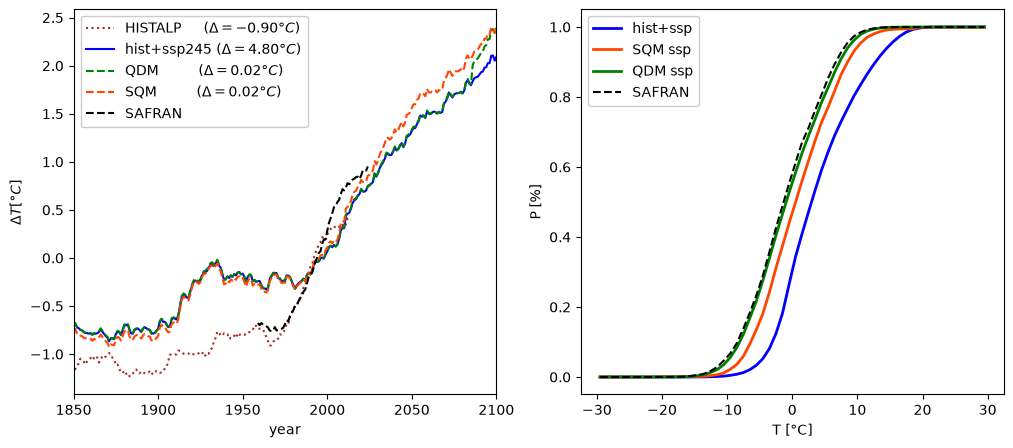

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#####################################
#A
#
temp_histalp_trend.plot(ax=ax[0],linestyle=':',color='brown',
                         label='HISTALP     ($\Delta=%.2f°C$)'%(ref_histalp-ref_saf))

temp_ssp_trend.plot(ax=ax[0],color='blue',# label='MPI hist+ssp245',
                         label='hist+ssp245 ($\Delta=%.2f°C$)'%(ref_ssp-ref_saf))
temp_ssp_cor_trend.plot(ax=ax[0],ls='--', color='green',#  label='QDM') 
                         label='QDM         ($\Delta=%.2f°C$)'%(ref_cor-ref_saf))

temp_ssp_cor_sqm_trend.plot(ax=ax[0],ls='--', color='orangered',#  label='SQM') 
                         label='SQM         ($\Delta=%.2f°C$)'%(ref_sqm-ref_saf))

temp_saf_trend.plot(ax=ax[0],linestyle='--',color='black',
                         label='SAFRAN')
ax[0].legend(framealpha=1)
ax[0].set_xlim(1850,2100)
#ax[0].set_ylim(-1.5,1.8)
ax[0].set_xlabel('year')
ax[0].set_ylabel(f'$\Delta T [°C]$')
#ax[0].text(2005,-1.4,s='b',fontweight='bold',fontsize=13)

######################################
#B
#ax[0,1].fill_between(range_temp[:-1]+(delta_t/2),np.percentile(dist_prec_hist.cumsum(axis=1),0,axis=0),np.percentile(dist_prec_hist.cumsum(axis=1),100,axis=0),alpha=0.3,label=None,color='steelblue')
#ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_hist.mean(axis=0).cumsum(),label='historical',color='steelblue',linewidth=2)

#ax[0,1].fill_between(range_temp[:-1]+(delta_t/2),np.percentile(dist_prec_cor.cumsum(axis=1),0,axis=0),np.percentile(dist_prec_cor.cumsum(axis=1),100,axis=0),alpha=0.3,label=None,color='vibrant green')
########ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_cor.mean(axis=0).cumsum(),label='CDQM',color='vibrant green',linewidth=2)

#ax[0,1].fill_between(range_temp[:-1]+(delta_t/2),np.percentile(dist_prec_simpleMQM.cumsum(axis=1),0,axis=0),np.percentile(dist_prec_simpleMQM.cumsum(axis=1),100,axis=0),alpha=0.3,label=None,color='red')
#ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_cor.mean(axis=0).cumsum(),label='SQM hist',color='red',linewidth=2)

ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_ssp.cumsum(),label='hist+ssp',color='blue',linewidth=2)
ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_cor_sqm.cumsum(),label='SQM ssp',color='orangered',linewidth=2)
ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_cor.cumsum(),label='QDM ssp',color='green',linewidth=2)

ax[1].plot(range_temp[:-1]+(delta_t/2),dist_prec_saf.cumsum(),alpha=1,label='SAFRAN',color='black',linestyle='--')

ax[1].legend(framealpha=1,loc='upper left')
#ax[1].set_xlim(-15,18)
#ax[1].set_ylim(0,1)
ax[1].set_xlabel('T [°C]')
ax[1].set_ylabel('P [%]')
#ax[1].text(16,0.035,s='c',fontweight='bold',fontsize=13)

In [93]:
temp_saf_trend.shape

(66,)

Text(0, 0.5, 'Temperature ($°C$)')

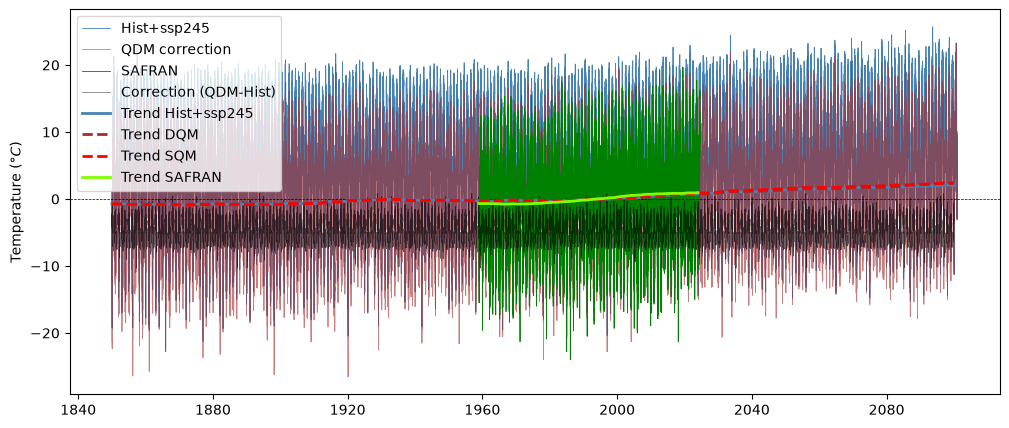

In [99]:
# Plot corrections.
fig, ax = plt.subplots( figsize=(12, 5))

ax.plot(temp_ssp.time,temp_ssp,linestyle='-',color='steelblue',linewidth=0.6,label='Hist+ssp245')
ax.plot(temp_ssp.time,temp_ssp_cor,linestyle='-',color='brown',alpha=.6,linewidth=0.6,label='QDM correction')

ax.plot(temp_saf.time,temp_saf,linestyle='-',color='green',alpha=1.0,linewidth=0.6,label='SAFRAN')

ax.plot(temp_ssp.time,temp_ssp_cor-temp_ssp,linestyle='-',color='k',alpha=.6,linewidth=0.5,label='Correction (QDM-Hist)')
plt.axhline(y=0., color='k', linestyle='--',lw=0.5)

#Trends
ax.plot(dates_trends,temp_ssp_trend,color='steelblue',lw=2,label='Trend Hist+ssp245')
ax.plot(dates_trends,temp_ssp_cor_trend,color='brown',lw=2,ls='--',label='Trend DQM')
ax.plot(dates_trends,temp_ssp_cor_sqm_trend,color='red',lw=2,ls='--',label='Trend SQM')
#Trend Safran
ax.plot(dates_trendsaf,temp_saf_trend,color='chartreuse',lw=2,label='Trend SAFRAN')
ax.legend()
ax.set_ylabel('Temperature ($°C$)')

# IPSL (IPSL-CM6A-LR)

## IPSL : correction calibration

**Temperature**

**Removed**

# Other GCM (CNRM, NOAA, ...)

TO DO